In [1006]:
from google.colab import drive
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [1007]:
data_folder = "/gdrive/MyDrive/data/"

In [1008]:
!ls /gdrive/MyDrive/data

bible_fra.txt	   glove.6B.100d.txt  Synthetic_Financial_datasets_log.csv.zip
births.csv	   glove.6B.200d.txt  tweets.csv
births_github.csv  glove.6B.300d.txt  WASTE_COURT.zip
decades.csv	   glove.6B.50d.txt   WASTE.zip
exemple.txt	   station.csv


# Import Data

In [1009]:
import pandas as pd

In [1010]:
df = pd.read_csv(data_folder + 'station.csv')

In [1011]:
len(df)

53

In [1012]:
# df = df.iloc[:-1]

In [1013]:
# len(df)

In [1014]:
df.describe()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,D-J-F,M-A-M,J-J-A,S-O-N,metANN
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,1999.000000,5.131509,5.556415,7.510377,9.346604,12.569811,34.103585,17.636604,17.728868,34.016038,30.818868,26.985094,24.705472,5.539434,9.808868,16.967170,30.606604,11.076226
std,15.443445,1.978247,2.012753,1.324834,1.251132,1.190510,135.218720,1.214431,1.228015,135.231366,135.681299,136.216820,136.539315,1.242591,0.928306,0.952283,135.706328,0.755259
min,1973.000000,-1.010000,-1.060000,4.570000,6.510000,9.790000,13.210000,15.480000,15.140000,12.840000,8.370000,4.270000,1.670000,2.990000,8.100000,14.780000,9.350000,9.550000
25%,1986.000000,4.280000,4.170000,6.430000,8.640000,11.560000,14.420000,16.520000,16.940000,14.600000,11.160000,7.590000,4.870000,4.680000,9.070000,16.450000,11.360000,10.540000
50%,1999.000000,5.270000,5.630000,7.630000,9.150000,12.770000,15.560000,17.790000,17.700000,15.360000,12.070000,8.260000,6.060000,5.760000,10.020000,17.020000,11.940000,10.980000
75%,2012.000000,6.750000,7.140000,8.540000,10.160000,13.180000,16.260000,18.560000,18.430000,16.270000,13.190000,9.160000,7.190000,6.340000,10.510000,17.510000,12.460000,11.550000
max,2025.000000,7.960000,9.500000,10.080000,12.140000,14.660000,999.900000,19.990000,20.350000,999.900000,999.900000,999.900000,999.900000,7.750000,11.420000,18.880000,999.900000,12.700000


In [1015]:
df.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,D-J-F,M-A-M,J-J-A,S-O-N,metANN
0,1973,4.12,4.20,5.97,7.89,12.18,14.99,16.30,18.10,15.18,11.08,7.29,5.64,4.36,8.68,16.46,11.18,10.17
1,1974,7.07,6.10,6.74,9.15,11.00,14.33,15.84,16.61,13.35,8.37,8.42,8.64,6.27,8.96,15.59,10.05,10.22
2,1975,7.96,5.72,5.69,8.69,10.39,14.42,17.47,19.05,15.15,10.51,7.10,3.52,7.44,8.26,16.98,10.92,10.90
3,1976,5.75,4.92,6.00,8.03,13.18,17.40,19.10,18.09,15.18,12.07,7.59,3.49,4.73,9.07,18.20,11.61,10.90
4,1977,4.15,7.39,8.24,7.94,11.23,13.21,16.22,15.55,13.40,12.72,7.94,7.43,5.01,9.14,14.99,11.35,10.12


In [1016]:
df.tail()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,D-J-F,M-A-M,J-J-A,S-O-N,metANN
48,2021,5.09,6.44,7.64,7.29,11.64,16.74,18.09,17.19,17.29,12.79,8.24,7.54,6.14,8.86,17.34,12.77,11.28
49,2022,5.69,7.54,9.19,9.84,14.19,16.94,19.69,19.94,16.29,15.09,10.44,5.00,6.92,11.07,18.86,13.94,12.70
50,2023,6.75,6.90,9.35,10.05,13.20,18.00,18.25,18.40,19.15,14.65,9.75,8.65,6.22,10.87,18.22,14.52,12.45
51,2024,5.10,9.50,9.30,10.90,14.05,15.25,18.25,19.50,15.40,13.25,9.00,7.40,7.75,11.42,17.67,12.55,12.35
52,2025,4.55,5.80,8.35,11.75,13.95,18.30,18.95,19.10,999.90,999.90,999.90,999.90,5.92,11.35,18.78,999.90,12.31


# Créer la série temporelle

In [1017]:
temps = df.loc[:, "JAN" : "DEC"]
temps

,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,4.12,4.20,5.97,7.89,12.18,14.99,16.30,18.10,15.18,11.08,7.29,5.64
1,7.07,6.10,6.74,9.15,11.00,14.33,15.84,16.61,13.35,8.37,8.42,8.64
2,7.96,5.72,5.69,8.69,10.39,14.42,17.47,19.05,15.15,10.51,7.10,3.52
3,5.75,4.92,6.00,8.03,13.18,17.40,19.10,18.09,15.18,12.07,7.59,3.49
4,4.15,7.39,8.24,7.94,11.23,13.21,16.22,15.55,13.40,12.72,7.94,7.43
5,4.28,3.71,7.59,7.82,11.56,13.62,15.57,15.14,14.60,12.73,9.16,5.18
6,0.46,3.34,6.20,8.35,10.77,13.79,16.52,15.49,14.38,11.95,8.17,7.04
7,1.98,7.01,5.85,8.60,11.17,14.42,15.48,17.11,15.46,10.31,6.53,5.13
8,5.55,3.30,9.56,8.36,11.76,13.80,16.12,16.89,15.03,10.49,8.33,4.68
9,4.54,5.63,6.06,8.68,12.99,16.89,17.22,16.88,16.33,11.10,8.63,5.11


In [1018]:
series = []

for i , row in temps.iterrows():
  series += list(row)

In [1019]:
print(series)

[4.12, 4.2, 5.97, 7.89, 12.18, 14.99, 16.3, 18.1, 15.18, 11.08, 7.29, 5.64, 7.07, 6.1, 6.74, 9.15, 11.0, 14.33, 15.84, 16.61, 13.35, 8.37, 8.42, 8.64, 7.96, 5.72, 5.69, 8.69, 10.39, 14.42, 17.47, 19.05, 15.15, 10.51, 7.1, 3.52, 5.75, 4.92, 6.0, 8.03, 13.18, 17.4, 19.1, 18.09, 15.18, 12.07, 7.59, 3.49, 4.15, 7.39, 8.24, 7.94, 11.23, 13.21, 16.22, 15.55, 13.4, 12.72, 7.94, 7.43, 4.28, 3.71, 7.59, 7.82, 11.56, 13.62, 15.57, 15.14, 14.6, 12.73, 9.16, 5.18, 0.46, 3.34, 6.2, 8.35, 10.77, 13.79, 16.52, 15.49, 14.38, 11.95, 8.17, 7.04, 1.98, 7.01, 5.85, 8.6, 11.17, 14.42, 15.48, 17.11, 15.46, 10.31, 6.53, 5.13, 5.55, 3.3, 9.56, 8.36, 11.76, 13.8, 16.12, 16.89, 15.03, 10.49, 8.33, 4.68, 4.54, 5.63, 6.06, 8.68, 12.99, 16.89, 17.22, 16.88, 16.33, 11.1, 8.63, 5.11, 7.11, 1.82, 6.55, 7.95, 11.22, 15.09, 19.99, 17.7, 16.04, 11.64, 8.14, 5.35, 5.81, 4.98, 5.89, 9.18, 9.79, 14.88, 18.07, 18.55, 15.15, 11.94, 9.61, 5.38, 0.65, 2.99, 5.58, 9.18, 11.55, 14.14, 17.51, 15.78, 15.7, 11.32, 5.02, 6.84, 5.37,

In [1020]:
53*12

636

In [1021]:
len(series)

636

In [1022]:
series = series[:-4]

In [1023]:
len(series)

632

In [1024]:
import numpy as np

In [1025]:
series = np.array(series)

In [1026]:
series

array([ 4.120e+00,  4.200e+00,  5.970e+00,  7.890e+00,  1.218e+01,
        1.499e+01,  1.630e+01,  1.810e+01,  1.518e+01,  1.108e+01,
        7.290e+00,  5.640e+00,  7.070e+00,  6.100e+00,  6.740e+00,
        9.150e+00,  1.100e+01,  1.433e+01,  1.584e+01,  1.661e+01,
        1.335e+01,  8.370e+00,  8.420e+00,  8.640e+00,  7.960e+00,
        5.720e+00,  5.690e+00,  8.690e+00,  1.039e+01,  1.442e+01,
        1.747e+01,  1.905e+01,  1.515e+01,  1.051e+01,  7.100e+00,
        3.520e+00,  5.750e+00,  4.920e+00,  6.000e+00,  8.030e+00,
        1.318e+01,  1.740e+01,  1.910e+01,  1.809e+01,  1.518e+01,
        1.207e+01,  7.590e+00,  3.490e+00,  4.150e+00,  7.390e+00,
        8.240e+00,  7.940e+00,  1.123e+01,  1.321e+01,  1.622e+01,
        1.555e+01,  1.340e+01,  1.272e+01,  7.940e+00,  7.430e+00,
        4.280e+00,  3.710e+00,  7.590e+00,  7.820e+00,  1.156e+01,
        1.362e+01,  1.557e+01,  1.514e+01,  1.460e+01,  1.273e+01,
        9.160e+00,  5.180e+00,  4.600e-01,  3.340e+00,  6.200e

In [1027]:
series.shape

(632,)

# Data Visualization

In [1028]:
import matplotlib.pyplot as plt

In [1029]:
time = np.arange(len(series))

In [1030]:
time

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

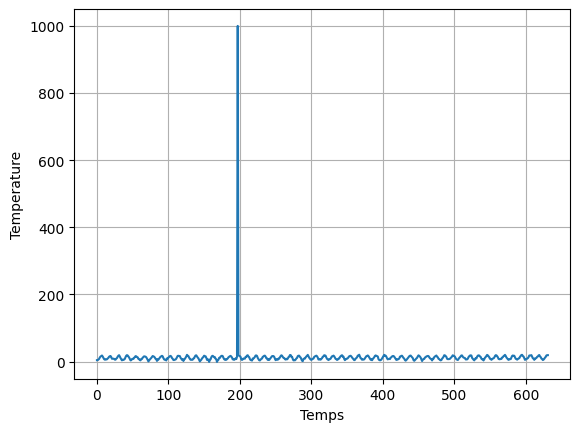

In [1031]:
plt.plot(time, series)
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.grid()
plt.show()

In [1032]:
np.argmax(series)

np.int64(197)

In [1033]:
series[197]

np.float64(999.9)

In [1034]:
extraits = series[196:199]
extraits

array([ 14.16, 999.9 ,  18.63])

In [1035]:
extraits = np.delete(extraits, 1)
extraits

array([14.16, 18.63])

In [1036]:
np.mean(extraits)

np.float64(16.395)

In [1037]:
series.max()

np.float64(999.9)

In [1038]:
series[197] = np.mean(extraits)

In [1039]:
series[196:199]

array([14.16 , 16.395, 18.63 ])

In [1040]:
series.max()

np.float64(20.35)

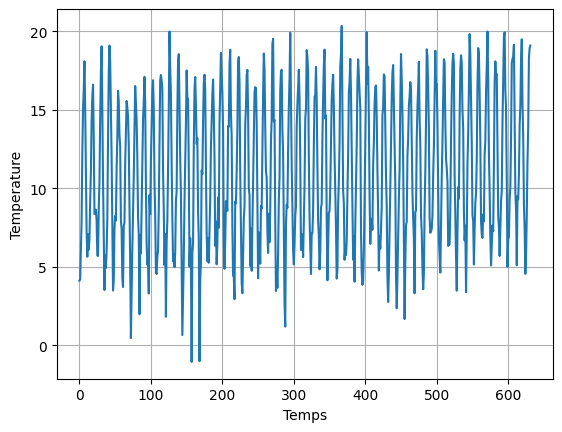

In [1041]:
plt.plot(time, series)
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.grid()
plt.show()

# Baseline (Modèle le + simple possible)

In [1042]:
len(series)*.80

505.6

In [1043]:
split = 532 # pour être env. 80% mais avoir pile 100 vals pour test

In [1044]:
# train_test_split

time_train = time[:split]
x_train = series[:split]

time_test = time[split:]
x_test = series[split:]

In [1045]:
years = df['YEAR'].tolist()
print (len(years), years)

53 [1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [1046]:
split/12

44.333333333333336

In [1047]:
years[44] # 1973-2016 train, 2016-2025 test

2017

## Approche naïve

In [1048]:
pred_naive = series[split-1:-1]
len(pred_naive)

100

In [1049]:
pred_naive.shape

(100,)

In [1050]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [1051]:
mean_absolute_error(x_test, pred_naive)

2.4012999999999995

In [1052]:
mean_squared_error(x_test, pred_naive) # = val_loss

8.147757

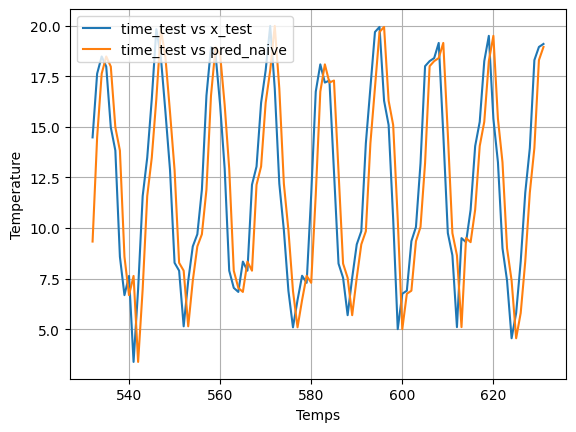

In [1053]:
plt.plot(time_test, x_test, label='time_test vs x_test')
plt.plot(time_test, pred_naive, label='time_test vs pred_naive')
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.legend(loc='upper left')
plt.grid()
plt.show()

 # Deep Learning

## Creer un windowed dataset

In [1054]:
import tensorflow as tf

In [1055]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window: window.batch(5))

for window in dataset:
  print(window.numpy())

[0 1 2 3 4]
[1 2 3 4 5]
[2 3 4 5 6]
[3 4 5 6 7]
[4 5 6 7 8]
[5 6 7 8 9]


In [1056]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1]))

In [1057]:
for x, y in dataset:
  print(x.numpy(), y.numpy())

[0 1 2 3] 4
[1 2 3 4] 5
[2 3 4 5] 6
[3 4 5 6] 7
[4 5 6 7] 8
[5 6 7 8] 9


In [1058]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
dataset = dataset.shuffle(buffer_size=10)

for x, y in dataset:
  print(x.numpy(), y.numpy())


[5 6 7 8] 9
[1 2 3 4] 5
[2 3 4 5] 6
[3 4 5 6] 7
[4 5 6 7] 8
[0 1 2 3] 4


In [1059]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
dataset = dataset.shuffle(buffer_size=10)

dataset = dataset.batch(2).prefetch(1)

for x, y in dataset:
  print(x.numpy(), y.numpy())

[[4 5 6 7]
 [2 3 4 5]] [8 6]
[[0 1 2 3]
 [3 4 5 6]] [4 7]
[[1 2 3 4]
 [5 6 7 8]] [5 9]


In [1060]:
dataset = tf.data.Dataset.from_tensor_slices(series)
dataset = dataset.window(5, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
dataset = dataset.shuffle(buffer_size=len(series))

dataset = dataset.batch(32).prefetch(1)

for x, y in dataset:
  print(x.numpy(), y.numpy())

[[ 5.15  6.47  8.25  8.83]
 [ 8.76  9.01 13.04 15.84]
 [17.55 14.91  9.99  9.57]
 [ 8.12  6.8   3.31  8.47]
 [ 7.96  5.72  5.69  8.69]
 [ 6.2   8.35 10.77 13.79]
 [16.64 17.24 15.24 12.14]
 [13.8  16.12 16.89 15.03]
 [18.4  19.15 14.65  9.75]
 [ 4.57  8.67 11.05 14.27]
 [16.08 16.45 16.38 14.2 ]
 [ 7.4   4.55  5.8   8.35]
 [13.34  7.59  4.44  4.35]
 [15.25 18.25 19.5  15.4 ]
 [16.52 15.49 14.38 11.95]
 [12.74 15.84 15.94 17.74]
 [11.64  8.14  5.35  5.81]
 [15.91 16.94 14.89 11.97]
 [ 7.42  8.27 10.87 12.66]
 [14.38 11.95  8.17  7.04]
 [ 7.54  5.69  7.54  9.19]
 [ 8.83 13.89 15.36 16.42]
 [12.99 16.89 17.22 16.88]
 [ 5.09  6.44  7.64  7.29]
 [12.14 13.04 16.19 17.79]
 [ 8.36 11.76 13.8  16.12]
 [14.64  8.04  4.14  6.44]
 [ 4.25  4.85  8.95 10.45]
 [ 9.25 13.05 16.55 19.95]
 [ 9.19  8.93  8.57 13.96]
 [ 4.93  3.66  5.83  9.24]
 [14.42 15.48 17.11 15.46]] [13.89 17.84  5.06  8.61 10.39 16.52  9.64 10.49  8.65 18.86  9.57 11.75
  2.94 13.25  8.17 15.64  4.98  6.34 15.67  1.98  9.84 17.56 1

In [1061]:
def windowed_dataset(series, window_size, batch_size):
  dataset = tf.data.Dataset.from_tensor_slices(series)
  dataset = dataset.window(window_size+1, shift=1, drop_remainder=True)
  dataset = dataset.flat_map(lambda window: window.batch(window_size+1))
  dataset = dataset.map(lambda window: (window[:-1], window[-1]))
  # dataset = dataset.shuffle(buffer_size=len(series))

  dataset = dataset.batch(batch_size).prefetch(1)

  return dataset

In [1062]:
window_size = 24
batch_size = 32
dataset = windowed_dataset(x_train, window_size, batch_size)
test_dataset = windowed_dataset(x_test, window_size, batch_size)

# Réseaux de Neurones profonds

In [1063]:
for feature, label in test_dataset.take(1):
  print(feature)
  print(label)

tf.Tensor(
[[14.48 17.63 18.48 17.98 14.98 13.83  8.58  6.68  7.63  3.38  6.98 11.58
  13.48 16.38 19.83 18.43 15.73 12.88  8.28  7.89  5.14  7.39  9.09  9.69]
 [17.63 18.48 17.98 14.98 13.83  8.58  6.68  7.63  3.38  6.98 11.58 13.48
  16.38 19.83 18.43 15.73 12.88  8.28  7.89  5.14  7.39  9.09  9.69 11.89]
 [18.48 17.98 14.98 13.83  8.58  6.68  7.63  3.38  6.98 11.58 13.48 16.38
  19.83 18.43 15.73 12.88  8.28  7.89  5.14  7.39  9.09  9.69 11.89 16.54]
 [17.98 14.98 13.83  8.58  6.68  7.63  3.38  6.98 11.58 13.48 16.38 19.83
  18.43 15.73 12.88  8.28  7.89  5.14  7.39  9.09  9.69 11.89 16.54 18.94]
 [14.98 13.83  8.58  6.68  7.63  3.38  6.98 11.58 13.48 16.38 19.83 18.43
  15.73 12.88  8.28  7.89  5.14  7.39  9.09  9.69 11.89 16.54 18.94 18.59]
 [13.83  8.58  6.68  7.63  3.38  6.98 11.58 13.48 16.38 19.83 18.43 15.73
  12.88  8.28  7.89  5.14  7.39  9.09  9.69 11.89 16.54 18.94 18.59 16.09]
 [ 8.58  6.68  7.63  3.38  6.98 11.58 13.48 16.38 19.83 18.43 15.73 12.88
   8.28  7.89  5.14  

In [1064]:
for feature, label in test_dataset.take(1):
  print(feature.shape)
  print(label.shape)

(32, 24)
(32,)


In [1065]:
# model = tf.keras.models.Sequential([
#     tf.keras.layers.Dense(10, input_shape=[24], activation='relu'),
#     tf.keras.layers.Dense(10,  activation='relu'),
#     tf.keras.layers.Dense(1)
# ])

In [1066]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=[window_size]),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10,  activation='relu'),
    tf.keras.layers.Dense(1)
])

In [1067]:
model.summary()

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_76 (Dense)                │ (None, 10)             │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [1068]:
model.compile(loss='mse', optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))


In [1069]:
h = model.fit(dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 176.2495 - val_loss: 150.5352
Epoch 2/100
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 119.2062

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 104.9193 - val_loss: 99.5341
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 76.1654 - val_loss: 79.0178
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 63.0171 - val_loss: 66.2936
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 54.6492 - val_loss: 57.2466
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.5736 - val_loss: 50.4390
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44.0671 - val_loss: 45.3321
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40.7472 - val_loss: 41.5931
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 38.3160 - val_loss: 38.8573
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36.4812 - val_loss: 36.7775
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 34.9921 - val_loss: 35.0643
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 33.6645 - val_loss: 33.5367
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/ste

# Prediction avec reseaux de neurones

In [1070]:
len(x_test), x_test

(100,
 array([14.48, 17.63, 18.48, 17.98, 14.98, 13.83,  8.58,  6.68,  7.63,
         3.38,  6.98, 11.58, 13.48, 16.38, 19.83, 18.43, 15.73, 12.88,
         8.28,  7.89,  5.14,  7.39,  9.09,  9.69, 11.89, 16.54, 18.94,
        18.59, 16.09, 12.94,  7.89,  7.04,  6.84,  8.34,  7.89, 12.14,
        13.04, 16.19, 17.79, 19.99, 16.89, 12.19,  9.89,  6.89,  5.09,
         6.44,  7.64,  7.29, 11.64, 16.74, 18.09, 17.19, 17.29, 12.79,
         8.24,  7.54,  5.69,  7.54,  9.19,  9.84, 14.19, 16.94, 19.69,
        19.94, 16.29, 15.09, 10.44,  5.  ,  6.75,  6.9 ,  9.35, 10.05,
        13.2 , 18.  , 18.25, 18.4 , 19.15, 14.65,  9.75,  8.65,  5.1 ,
         9.5 ,  9.3 , 10.9 , 14.05, 15.25, 18.25, 19.5 , 15.4 , 13.25,
         9.  ,  7.4 ,  4.55,  5.8 ,  8.35, 11.75, 13.95, 18.3 , 18.95,
        19.1 ]))

In [1071]:
series[split-24:split].shape

(24,)

In [1072]:
r = model.predict(series[split-24:split].reshape(1, -1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [1073]:
r

array([[14.402938]], dtype=float32)

In [1074]:
r.item()

14.402937889099121

In [1075]:
forecast = [] # = prévision

for time in range(split-24, split+100-24):

  series_to_predict = series[time: time+24].reshape(1, -1)
  r = model.predict(series_to_predict)
  forecast.append(r.item())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

In [1076]:
print(forecast)

[14.402937889099121, 16.60721206665039, 19.748891830444336, 17.979585647583008, 16.383033752441406, 11.440513610839844, 7.552541255950928, 7.445252418518066, 3.8639068603515625, 5.311612129211426, 9.389848709106445, 11.3758544921875, 13.3278226852417, 16.514110565185547, 16.68154525756836, 16.794620513916016, 16.23405647277832, 14.357366561889648, 10.357726097106934, 6.196957588195801, 4.630553245544434, 7.625428676605225, 7.791903495788574, 10.536324501037598, 15.222430229187012, 16.18484115600586, 17.095142364501953, 18.125551223754883, 15.498544692993164, 13.645983695983887, 8.595685958862305, 8.599991798400879, 7.167211055755615, 5.562819004058838, 8.907806396484375, 12.577710151672363, 13.606840133666992, 15.540739059448242, 17.581636428833008, 16.883419036865234, 15.236775398254395, 13.53337574005127, 10.219365119934082, 6.7786173820495605, 4.837215900421143, 6.668123245239258, 9.179197311401367, 11.06064224243164, 14.480534553527832, 15.694564819335938, 17.615821838378906, 18.27

In [1077]:
forecast = np.array(forecast)

mae :  1.3259006143569942
mse :  2.7693782543624454


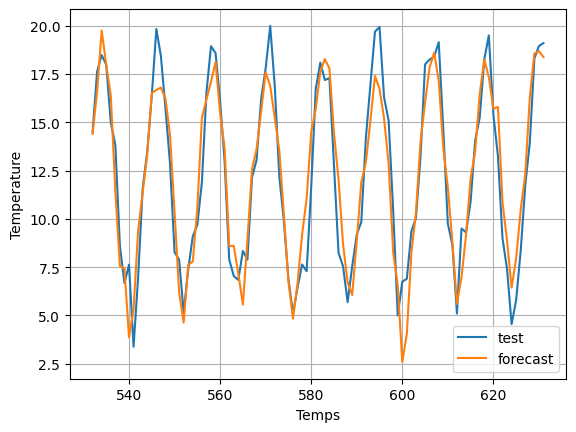

In [1078]:
print('mae : ', mean_absolute_error(x_test, forecast))
print('mse : ', mean_squared_error(x_test, forecast))
plt.plot(time_test, x_test, label = 'test')
plt.plot(time_test, forecast, label = 'forecast')
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

# Réseaux convolutionnels CNN

In [1079]:
series.shape

(632,)

In [1080]:
series.reshape(-1, 1).shape

(632, 1)

In [1081]:
def windowed_dataset(series, window_size, batch_size):
  series = series.reshape(-1, 1)
  dataset = tf.data.Dataset.from_tensor_slices(series)
  dataset = dataset.window(window_size+1, shift=1, drop_remainder=True)
  dataset = dataset.flat_map(lambda window: window.batch(window_size+1))
  dataset = dataset.map(lambda window: (window[:-1], window[-1]))
  # dataset = dataset.shuffle(buffer_size=len(series))

  dataset = dataset.batch(batch_size).prefetch(1)

  return dataset

In [1082]:
dataset = windowed_dataset(x_train, window_size, batch_size)
test_dataset = windowed_dataset(x_test, window_size, batch_size)

In [1083]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=[None, 1]),
    tf.keras.layers.Conv1D(filters=128, kernel_size=3, padding='causal',
                           activation='relu'),
    tf.keras.layers.Dense(28, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [1084]:
model.summary()

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, None, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, None, 28)       │         3,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, None, 10)       │           290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, None, 1)        │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,425 (17.29 KB)

 Trainable params: 4,425 (17.29 KB)

 Non-trainable params: 0 (0.00 B)

In [1085]:
model.compile(loss='mse', optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))
h = model.fit(dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 143.8023 - val_loss: 183.3536
Epoch 2/100
10/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 135.6293 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 138.2963 - val_loss: 174.8600
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 132.6417 - val_loss: 170.2839
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 129.0514 - val_loss: 164.6823
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 124.2481 - val_loss: 155.6696
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 116.5403 - val_loss: 141.9895
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 106.0327 - val_loss: 126.5557
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 94.4781 - val_loss: 110.0145
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 82.7967 - val_loss: 95.7156
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 72.9772 - val_loss: 83.6825
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 64.8543 - val_loss: 73.7453
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 58.2704 - val_loss: 65.7413
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━

In [1086]:
def predict_dataset(model, series, window_size):

  dataset = tf.data.Dataset.from_tensor_slices(series)
  dataset = dataset.window(window_size, shift=1, drop_remainder=True)
  dataset = dataset.flat_map(lambda window: window.batch(window_size))

  # dataset = dataset.shuffle(buffer_size=len(series))

  dataset = dataset.batch(32).prefetch(1)
  forecast = model.predict(dataset)

  return forecast

In [1087]:
len(x_test), x_test

(100,
 array([14.48, 17.63, 18.48, 17.98, 14.98, 13.83,  8.58,  6.68,  7.63,
         3.38,  6.98, 11.58, 13.48, 16.38, 19.83, 18.43, 15.73, 12.88,
         8.28,  7.89,  5.14,  7.39,  9.09,  9.69, 11.89, 16.54, 18.94,
        18.59, 16.09, 12.94,  7.89,  7.04,  6.84,  8.34,  7.89, 12.14,
        13.04, 16.19, 17.79, 19.99, 16.89, 12.19,  9.89,  6.89,  5.09,
         6.44,  7.64,  7.29, 11.64, 16.74, 18.09, 17.19, 17.29, 12.79,
         8.24,  7.54,  5.69,  7.54,  9.19,  9.84, 14.19, 16.94, 19.69,
        19.94, 16.29, 15.09, 10.44,  5.  ,  6.75,  6.9 ,  9.35, 10.05,
        13.2 , 18.  , 18.25, 18.4 , 19.15, 14.65,  9.75,  8.65,  5.1 ,
         9.5 ,  9.3 , 10.9 , 14.05, 15.25, 18.25, 19.5 , 15.4 , 13.25,
         9.  ,  7.4 ,  4.55,  5.8 ,  8.35, 11.75, 13.95, 18.3 , 18.95,
        19.1 ]))

In [1088]:
series[split-24:-1].shape

(123,)

In [1089]:
cnn_forecast = predict_dataset(model, series[split-24:-1], window_size)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [1090]:
cnn_forecast.shape

(100, 24, 1)

In [1091]:
results = cnn_forecast[:, -1, 0]

In [1092]:
results

array([ 7.790083 , 10.753503 , 13.115219 , 14.629488 , 15.106886 ,
       14.135369 , 13.24208  , 10.253525 ,  8.665714 ,  6.833897 ,
        4.7733974,  6.049503 ,  8.00624  , 10.195011 , 12.475939 ,
       14.981713 , 15.230548 , 14.9339905, 13.168937 , 10.3425255,
        8.669346 ,  5.9667325,  6.407193 ,  6.9390087,  7.783188 ,
        9.24948  , 12.070523 , 14.416491 , 15.158978 , 14.759958 ,
       13.285427 , 10.357956 ,  8.372141 ,  6.309652 ,  6.741932 ,
        6.6647744,  9.051788 , 10.156091 , 12.402821 , 13.858304 ,
       15.657504 , 14.8543625, 13.654939 , 11.24785  ,  8.2354965,
        6.466894 ,  5.67354  ,  5.9974174,  6.183355 ,  8.59795  ,
       11.927013 , 13.998451 , 14.467836 , 14.799234 , 12.843041 ,
       10.916637 ,  8.51574  ,  6.097651 ,  6.4060287,  7.0656776,
        7.893664 , 10.458913 , 12.741693 , 15.086962 , 16.023571 ,
       15.252968 , 14.53457  , 11.484473 ,  8.782312 ,  7.0279584,
        5.6725483,  7.193043 ,  7.976239 , 10.003858 , 13.1110

mae :  3.738301840782165
mse :  18.268014856061416


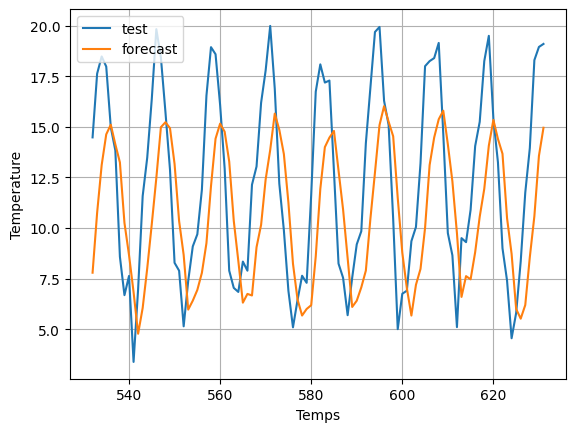

In [1093]:
print('mae : ', mean_absolute_error(x_test, results))
print('mse : ', mean_squared_error(x_test, results))
plt.plot(time_test, x_test, label = 'test')
plt.plot(time_test, results, label = 'forecast')
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Reseaux de Neurones Récurrents RNN

In [1094]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=[None, 1]),
    tf.keras.layers.SimpleRNN(100, return_sequences=True),
    tf.keras.layers.SimpleRNN(100),
    tf.keras.layers.Dense(1)
])

In [1095]:
huber = tf.keras.losses.Huber()
model.compile(loss=huber, optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))
h = model.fit(dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
     11/Unknown 1s 11ms/step - loss: 10.2838

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 10.4163 - val_loss: 12.2552
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 10.4015 - val_loss: 12.2339
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 10.3809 - val_loss: 12.2111
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 10.3593 - val_loss: 12.1879
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 10.3374 - val_loss: 12.1647
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 10.3155 - val_loss: 12.1414
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 10.2935 - val_loss: 12.1181
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 10.2716 - val_loss: 12.0948
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 10.2496 - val_loss: 12.0715
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 10.2276 - val_loss: 12.0481
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 10.2057 - val_loss: 12.0248
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s

In [1096]:
rnn_forecast = predict_dataset(model, series[split-24:-1], window_size)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [1097]:
rnn_forecast.shape

(100, 1)

In [1098]:
rnn_forecast = rnn_forecast[:, 0]

In [1099]:
rnn_forecast.shape

(100,)

In [1100]:
x_test.shape

(100,)

mae :  10.346473647260666
mse :  129.4640713191856


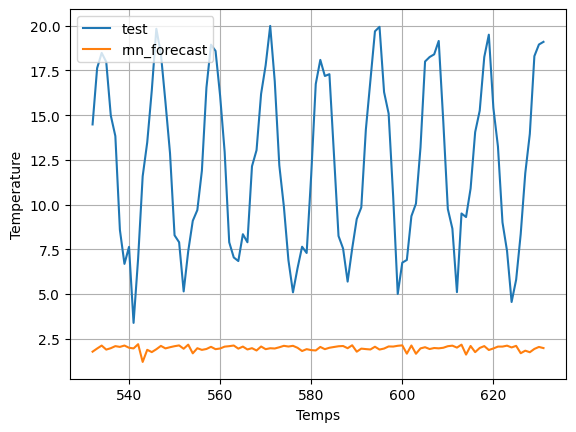

In [1101]:
print('mae : ', mean_absolute_error(x_test, rnn_forecast))
print('mse : ', mean_squared_error(x_test, rnn_forecast))
plt.plot(time_test, x_test, label = 'test')
plt.plot(time_test, rnn_forecast, label = 'rnn_forecast')
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# RNN Normalized

In [1102]:
x_train_scaled = (x_train - x_train.mean()) / x_train.std()
x_test_scaled = (x_test - x_train.mean()) / x_train.std()

In [1103]:
dataset = windowed_dataset(x_train_scaled, window_size, batch_size)
test_dataset = windowed_dataset(x_test_scaled, window_size, batch_size)

In [1104]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=[None, 1]),
    tf.keras.layers.SimpleRNN(100, return_sequences=True),
    tf.keras.layers.SimpleRNN(100),
    tf.keras.layers.Dense(1)
])

In [1105]:
huber = tf.keras.losses.Huber()
model.compile(loss=huber, optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))
model.fit(dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
     11/Unknown 1s 12ms/step - loss: 0.5400

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.5368 - val_loss: 0.5405
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5286 - val_loss: 0.5306
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5172 - val_loss: 0.5201
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.5053 - val_loss: 0.5096
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4936 - val_loss: 0.4992
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4819 - val_loss: 0.4890
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4705 - val_loss: 0.4790
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4592 - val_loss: 0.4692
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4481 - val_loss: 0.4595
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4373 - val_loss: 0.4501
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4266 - val_loss: 0.4408
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4

In [1106]:
series_scaled = (series - series.mean()) / series.std()

In [1107]:
rnn_forecast = predict_dataset(model, series_scaled[split-24:-1], window_size)[:, 0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


mae :  0.4127930553671886
mse :  0.2624067348715486


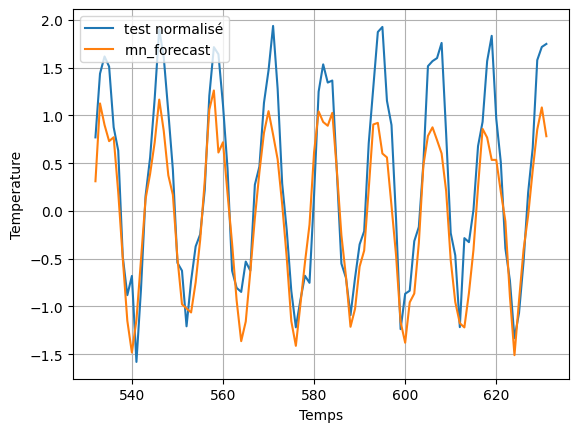

In [1108]:
print('mae : ', mean_absolute_error(x_test_scaled, rnn_forecast))
print('mse : ', mean_squared_error(x_test_scaled, rnn_forecast))
plt.plot(time_test, x_test_scaled, label = 'test normalisé')
plt.plot(time_test, rnn_forecast, label = 'rnn_forecast')
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# GRU (Gated Recurrent Unit _ Modèle de données récurent)

In [1109]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=[None, 1]),
    tf.keras.layers.GRU(100, return_sequences=True, dropout=0.1),
    tf.keras.layers.GRU(100),
    tf.keras.layers.Dense(1)
])

In [1110]:
huber = tf.keras.losses.Huber()
model.compile(loss=huber, optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))
model.fit(dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
     14/Unknown 3s 25ms/step - loss: 0.4487

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.4479 - val_loss: 0.4748
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4477 - val_loss: 0.4748
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.4480 - val_loss: 0.4748
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4474 - val_loss: 0.4748
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4492 - val_loss: 0.4748
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4476 - val_loss: 0.4748
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - loss: 0.4485 - val_loss: 0.4748
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4480 - val_loss: 0.4748
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4475 - val_loss: 0.4747
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4482 - val_loss: 0.4747
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4479 - val_loss: 0.4747
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.

In [1111]:
gru_forecast = predict_dataset(model, series_scaled[split-24:-1], window_size)[:, 0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


mae :  0.8843792780149478
mse :  1.0374215299520273


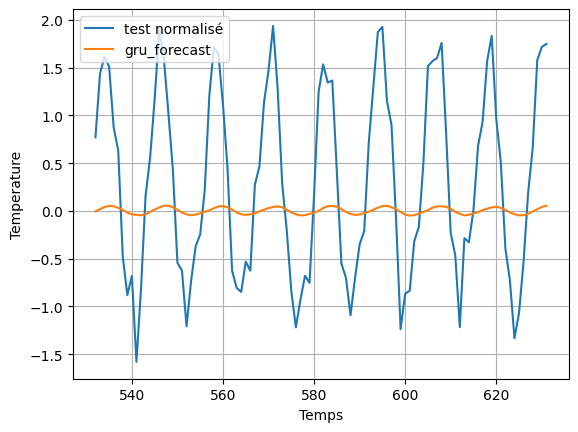

In [1112]:
print('mae : ', mean_absolute_error(x_test_scaled, gru_forecast))
print('mse : ', mean_squared_error(x_test_scaled, gru_forecast))
plt.plot(time_test, x_test_scaled, label = 'test normalisé')
plt.plot(time_test, gru_forecast, label = 'gru_forecast')
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.legend(loc='upper left')
plt.grid()
plt.show()

# LSTM

In [1113]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=[None, 1]),
    tf.keras.layers.LSTM(24, return_sequences=True),
    tf.keras.layers.LSTM(24),
    tf.keras.layers.Dense(1)
])

In [1114]:
huber = tf.keras.losses.Huber()
model.compile(loss=huber, optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9))
model.fit(dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
     14/Unknown 2s 13ms/step - loss: 0.4747

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4739 - val_loss: 0.4947
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4

In [1115]:
lstm_forecast = predict_dataset(model, series_scaled[split-24:-1], window_size)[:, 0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


mae :  0.9145064915761942
mse :  1.0927925806138974


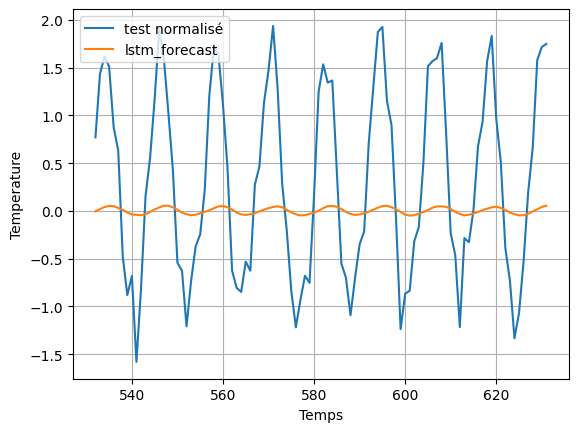

In [1116]:
print('mae : ', mean_absolute_error(x_test_scaled, lstm_forecast))
print('mse : ', mean_squared_error(x_test_scaled, lstm_forecast))
plt.plot(time_test, x_test_scaled, label = 'test normalisé')
plt.plot(time_test, gru_forecast, label = 'lstm_forecast')
plt.xlabel('Temps')
plt.ylabel('Temperature')
plt.legend(loc='upper left')
plt.grid()
plt.show()